# 4. Model Evaluation & Save Best Model

Deep-dive evaluation of the **top models** from notebook 3, then export the winner to `models/best_model/` so notebook 5 can load it directly.

| Saved file | Format | Load with |
|---|---|---|
| `models/best_model/best_model.pt` | PyTorch (YOLO) | `YOLO('...best_model.pt')` |
| `models/best_model/best_model_info.json` | JSON | `json.load(...)` |

> Results are cached in `models/best_model/deep_results_cache.json` — re-running skips inference if cache exists.


In [13]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'pandas', 'matplotlib', 'tqdm', 'scikit-learn']:
    install(pkg)
print('Dependencies ready.')


Dependencies ready.


In [14]:
import cv2, time, json, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT           = Path('..').resolve()
PD_DIR         = ROOT / 'person_detector'
DATASET_DIR    = PD_DIR / 'data' / 'dataset'
BEST_MODEL_DIR = PD_DIR / 'models' / 'best_model'
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

TEST_IMG_DIR   = DATASET_DIR / 'test' / 'images'
TEST_LABEL_DIR = DATASET_DIR / 'test' / 'labels'

PERSON_CLS  = 0
CONF_THRESH = 0.30
IOU_THRESH  = 0.50

DEEP_CACHE = BEST_MODEL_DIR / 'deep_results_cache.json'

test_images = sorted(TEST_IMG_DIR.glob('*.jpg')) + sorted(TEST_IMG_DIR.glob('*.png'))
print(f'Test images: {len(test_images)}')

# Load best model choice from notebook 3
choice_path = PD_DIR / 'best_model_choice.json'
if not choice_path.exists():
    raise FileNotFoundError('best_model_choice.json not found — run notebook 3 first.')

choice = json.loads(choice_path.read_text())
print(f"Best model  : {choice['model_id']}  ({choice['backend']})")
print(f"Score       : {choice['score']}  F1={choice['f1']}  IoU={choice['avg_iou']}  {choice['avg_ms']}ms")

if DEEP_CACHE.exists():
    print(f'\n[cache] Deep results cache found — cells 9+ will skip re-evaluation.')


Test images: 182
Best model  : yolo11m.pt  (YOLO)
Score       : 0.75  F1=1.0  IoU=1.0  145.4ms


## 4.1 Shared Helpers

In [15]:
def iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter  = max(0, xB-xA) * max(0, yB-yA)
    ua = (a[2]-a[0]) * (a[3]-a[1])
    ub = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (ua+ub-inter) if (ua+ub-inter) > 0 else 0.0

def read_gt(lp, w, h):
    if not lp.exists(): return None
    parts = lp.read_text().strip().split()
    if len(parts) < 5: return None
    _, cx, cy, bw, bh = map(float, parts[:5])
    return [(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h]

print('Helpers ready.')


Helpers ready.


## 4.2 Select Top-3 Models to Evaluate Deeply
Evaluate the winner from notebook 3 **plus** 2 runners-up on both val and test sets.

In [16]:
# Build eval list directly from notebook 3's ranked top3 — no hardcoding
# Each entry: (display_name, backend, model_identifier)
EVAL_MODELS = [
    (m['name'], m['backend'], m['model_id'])
    for m in choice['top3_models']
]

print('Models to deep-evaluate (from notebook 3 ranking):')
for name, backend, mid in EVAL_MODELS:
    print(f'  {name:30s}  backend={backend}  id={mid}')


Models to deep-evaluate (from notebook 3 ranking):
  yolo11m                         backend=YOLO  id=yolo11m.pt
  yolo11s                         backend=YOLO  id=yolo11s.pt
  yolov8s                         backend=YOLO  id=yolov8s.pt


In [17]:
EVAL_CACHE_DIR = BEST_MODEL_DIR / 'eval_cache'
EVAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _eval_cache_path(model_id: str) -> Path:
    return EVAL_CACHE_DIR / f"{model_id.replace('.pt','')}_deep.json"


def _load_eval_cache(model_id: str) -> dict | None:
    p = _eval_cache_path(model_id)
    if p.exists():
        data = json.loads(p.read_text())
        print(f'  [cache] {model_id} — loaded from {p.name}')
        return data
    return None


def _save_eval_cache(model_id: str, result: dict) -> None:
    # Save everything except per-frame records (too large) — keep only aggregate + records separately
    p = _eval_cache_path(model_id)
    p.write_text(json.dumps(result, indent=2))


def run_eval(model_id, images, label_dir, conf=CONF_THRESH):
    """
    Full per-frame YOLO evaluation.
    Loads from cache if available — avoids re-running inference.
    Returns aggregate metrics + per-frame records (infer_ms for latency analysis).
    """
    cached = _load_eval_cache(model_id)
    if cached is not None:
        return cached

    mdl     = YOLO(model_id)
    records = []
    tp = fp = fn = 0
    ious = []; times = []

    for img_path in tqdm(images, desc=f'  {model_id}', leave=False):
        img = cv2.imread(str(img_path))
        if img is None: continue
        h, w = img.shape[:2]
        gt   = read_gt(label_dir / f'{img_path.stem}.txt', w, h)

        t0  = time.perf_counter()
        res = mdl.predict(str(img_path), classes=[PERSON_CLS],
                          conf=conf, verbose=False)[0]
        ms  = (time.perf_counter() - t0) * 1000
        times.append(ms)

        pred = None
        if res.boxes is not None and len(res.boxes) > 0:
            boxes = res.boxes.xyxy.tolist()
            pred  = max(boxes, key=lambda b: (b[2]-b[0]) * (b[3]-b[1]))

        score = 0.0
        if gt is not None and pred is not None:
            score = iou(pred, gt)
            if score >= IOU_THRESH: tp += 1
            else:                   fp += 1; fn += 1
            ious.append(score)
        elif gt is not None:   fn += 1
        elif pred is not None: fp += 1

        records.append({
            'file'    : img_path.name,
            'gt'      : gt,
            'pred'    : pred,
            'iou'     : score,
            'infer_ms': round(ms, 2),
            'tp'      : int(gt is not None and pred is not None and score >= IOU_THRESH),
            'fp'      : int(gt is None and pred is not None),
            'fn'      : int(gt is not None and pred is None),
        })

    prec = tp / (tp + fp) if tp + fp else 0
    rec  = tp / (tp + fn) if tp + fn else 0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0
    result = {
        'precision'   : round(prec, 4),
        'recall'      : round(rec,  4),
        'f1'          : round(f1,   4),
        'avg_iou'     : round(float(np.mean(ious)) if ious else 0, 4),
        'avg_infer_ms': round(float(np.mean(times)), 2),
        'tp': tp, 'fp': fp, 'fn': fn,
        'records'     : records,
    }
    _save_eval_cache(model_id, result)
    return result


print('Evaluator ready (results cached per model in eval_cache/).')


Evaluator ready (results cached per model in eval_cache/).


In [18]:
# Run deep eval on test set (per-model results are cached; only reruns missing ones)
deep_results = {}

for name, backend, mid in EVAL_MODELS:
    print(f'\nEvaluating {name} ...')
    r = run_eval(mid, test_images, TEST_LABEL_DIR)
    deep_results[name] = r
    print(f"  P={r['precision']:.3f}  R={r['recall']:.3f}  "
          f"F1={r['f1']:.3f}  IoU={r['avg_iou']:.3f}  "
          f"tp={r['tp']} fp={r['fp']} fn={r['fn']}  "
          f"{r['avg_infer_ms']:.1f}ms")

summary_df = pd.DataFrame([
    {'model': n, **{k: v for k, v in r.items() if k != 'records'}}
    for n, r in deep_results.items()
])
print('\n=== Test Set Summary ===')
print(summary_df[['model', 'precision', 'recall', 'f1', 'avg_iou', 'avg_infer_ms']]
      .to_string(index=False))



Evaluating yolo11m ...


  P=0.995  R=0.995  F1=0.995  IoU=0.993  tp=181 fp=1 fn=1  155.7ms

Evaluating yolo11s ...


  P=0.962  R=0.962  F1=0.962  IoU=0.943  tp=175 fp=7 fn=7  71.7ms

Evaluating yolov8s ...


  P=0.977  R=0.951  F1=0.964  IoU=0.936  tp=173 fp=4 fn=9  78.3ms

=== Test Set Summary ===
  model  precision  recall     f1  avg_iou  avg_infer_ms
yolo11m     0.9945  0.9945 0.9945   0.9933        155.71
yolo11s     0.9615  0.9615 0.9615   0.9434         71.74
yolov8s     0.9774  0.9505 0.9638   0.9365         78.35


## 4.3 IoU Distribution per Model

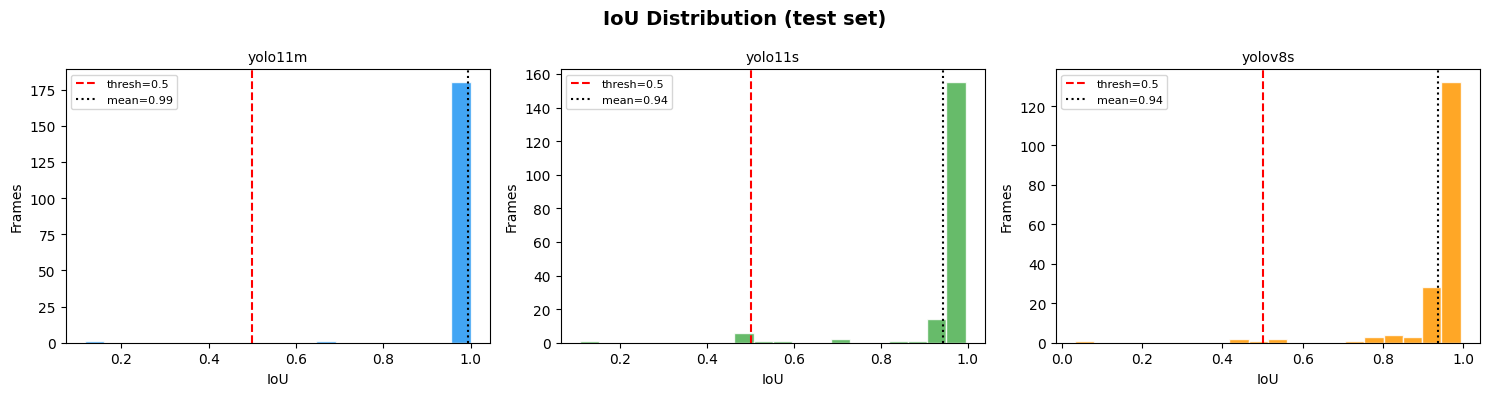

In [19]:
fig, axes = plt.subplots(1, len(deep_results), figsize=(5*len(deep_results), 4))
fig.suptitle('IoU Distribution (test set)', fontsize=14, fontweight='bold')
if len(deep_results) == 1:
    axes = [axes]

palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
for ax, (name, r), color in zip(axes, deep_results.items(), palette):
    ious = [rec['iou'] for rec in r['records'] if rec['iou'] > 0]
    if ious:
        ax.hist(ious, bins=20, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(IOU_THRESH, color='red', linestyle='--', label=f'thresh={IOU_THRESH}')
        ax.axvline(np.mean(ious), color='black', linestyle=':', label=f'mean={np.mean(ious):.2f}')
        ax.legend(fontsize=8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('IoU'); ax.set_ylabel('Frames')

plt.tight_layout()
plt.show()

## 4.4 Precision-Recall at Various Confidence Thresholds (YOLO only)

PR curve: yolo11m ...


PR curve: yolo11s ...


PR curve: yolov8s ...


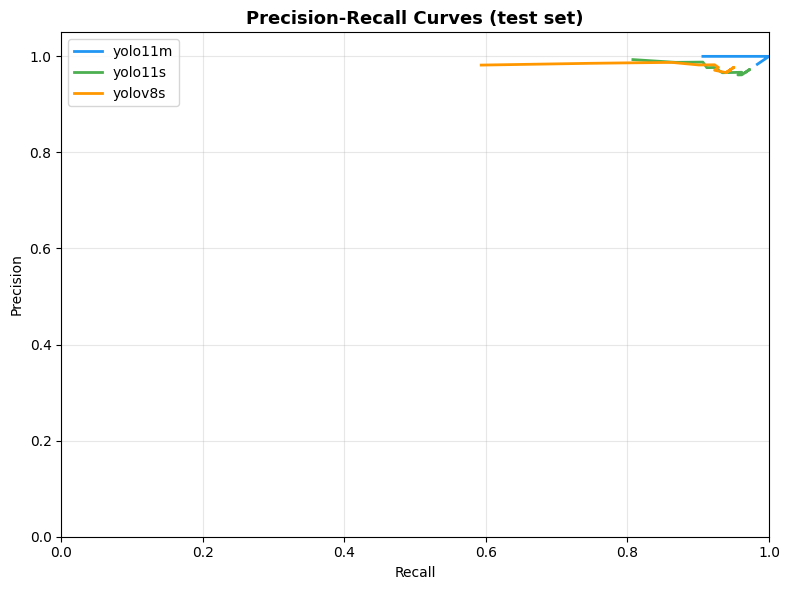

In [28]:
def pr_curve(model_id, images, label_dir, thresholds=None):
    """Compute precision/recall at multiple confidence thresholds."""
    if thresholds is None:
        thresholds = np.arange(0.1, 0.9, 0.05)
    mdl = YOLO(model_id)
    pts = []
    for conf in tqdm(thresholds, desc=f'  PR curve {model_id}', leave=False):
        tp=fp=fn=0
        for img_path in images:
            img = cv2.imread(str(img_path))
            if img is None: continue
            h,w = img.shape[:2]
            gt  = read_gt(label_dir/f'{img_path.stem}.txt', w, h)
            res = mdl.predict(str(img_path), classes=[PERSON_CLS],
                              conf=float(conf), verbose=False)[0]
            pred=None
            if res.boxes is not None and len(res.boxes)>0:
                boxes=res.boxes.xyxy.tolist()
                pred=max(boxes,key=lambda b:(b[2]-b[0])*(b[3]-b[1]))
            if gt and pred:
                if iou(pred,gt)>=IOU_THRESH: tp+=1
                else: fp+=1;fn+=1
            elif gt:  fn+=1
            elif pred: fp+=1
        prec=tp/(tp+fp) if tp+fp else 0
        rec =tp/(tp+fn) if tp+fn else 0
        pts.append({'conf':float(conf),'precision':prec,'recall':rec})
    return pd.DataFrame(pts)


# Run PR curves for YOLO models only
yolo_eval_models = [(n,mid) for n,backend,mid in EVAL_MODELS if backend=='YOLO']

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
for (name, mid), color in zip(yolo_eval_models, colors):
    print(f'PR curve: {name} ...')
    pr = pr_curve(mid, test_images, TEST_LABEL_DIR)
    ax.plot(pr['recall'], pr['precision'], label=name, color=color, linewidth=2)

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (test set)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
ax.legend()
plt.tight_layout()
plt.show()

## 4.5 Error Analysis — False Positives & False Negatives

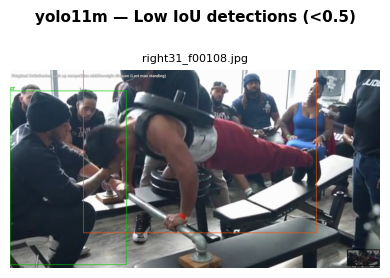

In [ ]:
def show_errors(name, r, images, n_show=4):
    """Visualise worst missed (FN) and worst spurious (FP) detections."""
    fn_recs = [rec for rec in r['records'] if rec['fn']]
    fp_recs = [rec for rec in r['records'] if rec['fp']]
    low_iou = sorted([rec for rec in r['records']
                      if rec['iou'] > 0 and rec['iou'] < IOU_THRESH],
                     key=lambda x: x['iou'])[:n_show]

    categories = [
        ('False Negatives (missed)',       fn_recs[:n_show]),
        ('False Positives (spurious)',     fp_recs[:n_show]),
        (f'Low IoU detections (<{IOU_THRESH})', low_iou),
    ]

    for title, recs in categories:
        if not recs: continue
        fig, axes = plt.subplots(1, len(recs), figsize=(4*len(recs), 3))
        if len(recs) == 1: axes = [axes]
        fig.suptitle(f'{name} — {title}', fontsize=11, fontweight='bold')
        img_lut = {p.name: p for p in images}
        for ax, rec in zip(axes, recs):
            img_path = img_lut.get(rec['file'])
            if img_path is None: ax.axis('off'); continue
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB).copy()
            if rec['gt']:
                x1, y1, x2, y2 = map(int, rec['gt'])
                cv2.rectangle(img, (x1,y1), (x2,y2), (0,200,0), 2)
                cv2.putText(img, 'GT', (x1, max(0,y1-5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,200,0), 2)
            if rec['pred']:
                x1, y1, x2, y2 = map(int, rec['pred'])
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,80,0), 2)
                cv2.putText(img, f"Pred IoU={rec['iou']:.2f}", (x1, max(0,y1-5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,80,0), 2)
            ax.imshow(img); ax.set_title(rec['file'][:20], fontsize=8); ax.axis('off')
        plt.tight_layout(); plt.show()


# Show errors for the best model (EVAL_MODELS[0] = top-1 from notebook 3)
best_name = EVAL_MODELS[0][0]
if best_name in deep_results:
    show_errors(best_name, deep_results[best_name], test_images)


## 4.6 Per-Frame Inference Latency Breakdown

/var/folders/cd/w5n36_jx0bg5lr_cx88kv7yw0000gn/T/ipykernel_52342/2838769672.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(bp_data, labels=bp_labels, patch_artist=True,


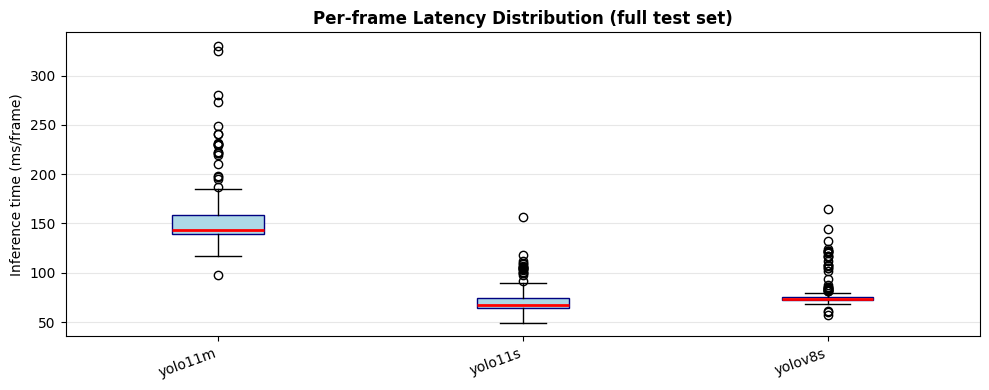

In [25]:
# Use per-frame infer_ms already collected in deep_results — no extra inference pass needed
fig, ax = plt.subplots(figsize=(10, 4))

bp_data   = [[ rec['infer_ms'] for rec in deep_results[name]['records'] ]
              for name, _, _ in EVAL_MODELS if name in deep_results]
bp_labels = [name for name, _, _ in EVAL_MODELS if name in deep_results]

ax.boxplot(bp_data, labels=bp_labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Inference time (ms/frame)')
ax.set_title('Per-frame Latency Distribution (full test set)', fontsize=12, fontweight='bold')
ax.set_xticklabels(bp_labels, rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 4.7 Final Ranking & Save Best Model

In [26]:
# Composite score on test set
df = summary_df.copy()
df['f1_norm']    = (df['f1'] - df['f1'].min()) / (df['f1'].max() - df['f1'].min() + 1e-9)
df['iou_norm']   = (df['avg_iou'] - df['avg_iou'].min()) / (df['avg_iou'].max() - df['avg_iou'].min() + 1e-9)
df['speed_norm'] = 1 - (df['avg_infer_ms'] - df['avg_infer_ms'].min()) / \
                       (df['avg_infer_ms'].max() - df['avg_infer_ms'].min() + 1e-9)
df['score']      = 0.55*df['f1_norm'] + 0.25*df['iou_norm'] + 0.20*df['speed_norm']

df_ranked = df[['model','precision','recall','f1','avg_iou','avg_infer_ms','score']]\
              .sort_values('score', ascending=False)

print('=== Final Ranking (55% F1 + 25% IoU + 20% Speed) ===')
print(df_ranked.to_string(index=False))

winner_row = df.loc[df['score'].idxmax()]
WINNER_NAME = winner_row['model']
print(f'\n🏆  Winner: {WINNER_NAME}  (score={winner_row["score"]:.4f})')

=== Final Ranking (55% F1 + 25% IoU + 20% Speed) ===
  model  precision  recall     f1  avg_iou  avg_infer_ms   score
yolo11m     0.9945  0.9945 0.9945   0.9933        155.71 0.80000
yolo11s     0.9615  0.9615 0.9615   0.9434         71.74 0.23037
yolov8s     0.9774  0.9505 0.9638   0.9365         78.35 0.22259

🏆  Winner: yolo11m  (score=0.8000)


In [27]:
# ── Save best model ───────────────────────────────────────────────────────────
BEST_PT   = BEST_MODEL_DIR / 'best_model.pt'
BEST_INFO = BEST_MODEL_DIR / 'best_model_info.json'

winner_mid = next(mid for name, backend, mid in EVAL_MODELS if name == WINNER_NAME)

# Download/cache weights then copy to best_model/
mdl_tmp = YOLO(winner_mid)
src_pt  = Path(mdl_tmp.ckpt_path)
shutil.copy(src_pt, BEST_PT)
print(f'Weights saved → {BEST_PT}  ({BEST_PT.stat().st_size/1024/1024:.1f} MB)')

# Save info JSON
info = {
    'model_name'   : WINNER_NAME,
    'backend'      : 'YOLO',
    'model_id'     : winner_mid,
    'pt_path'      : str(BEST_PT),
    'precision'    : float(winner_row['precision']),
    'recall'       : float(winner_row['recall']),
    'f1'           : float(winner_row['f1']),
    'avg_iou'      : float(winner_row['avg_iou']),
    'avg_infer_ms' : float(winner_row['avg_infer_ms']),
    'conf_thresh'  : CONF_THRESH,
    'iou_thresh'   : IOU_THRESH,
    'class_names'  : {0: 'closest_person'},
    'description'  : 'Detects the closest person (largest bbox) in each frame.',
}
BEST_INFO.write_text(json.dumps(info, indent=2))

print(f'Info JSON saved → {BEST_INFO}')
print()
print('=== models/best_model/ contents ===')
for p in sorted(BEST_MODEL_DIR.iterdir()):
    size = f'  {p.stat().st_size/1024/1024:.1f} MB' if p.is_file() else ''
    print(f'  {p.name}{size}')

print('\nNext step → 5.realtime_inference.ipynb')


Weights saved → /Users/haleytran/Downloads/pushup_judge/person_detector/models/best_model/best_model.pt  (38.8 MB)
Info JSON saved → /Users/haleytran/Downloads/pushup_judge/person_detector/models/best_model/best_model_info.json

=== models/best_model/ contents ===
  best_model.pt  38.8 MB
  best_model_info.json  0.0 MB
  eval_cache

Next step → 5.realtime_inference.ipynb
